# ROPAgen Document Evaluation
## ModernBERT-based NLP Metrics for 2,000-Token German GDPR Documents

**Metrics:** BLEU · ROUGE-1/2/L · METEOR · BERTScore Recall · SBERT Cosine Similarity  
**Model:** `answerdotai/ModernBERT-base` — Alternating Global-Local Attention + RoPE, 8,192-token native window  
**Hardware target:** RTX 4070 (CUDA) with batch processing to prevent OOM

In [1]:
import os, warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
load_dotenv()   # loads HF_TOKEN (and any other vars) from .env

import pandas as pd
import numpy as np
import torch
import evaluate
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm

# ── Configuration ──────────────────────────────────────────────────────────────
MODEL_NAME       = "answerdotai/ModernBERT-base"
DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"
BERT_BATCH_SIZE  = 4   # conservative for RTX 4070 + 2k-token docs
SBERT_BATCH_SIZE = 4

print(f"Device : {DEVICE}")
if DEVICE == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU    : {props.name}")
    print(f"VRAM   : {props.total_memory / 1e9:.1f} GB")
print(f"HF_TOKEN set: {bool(os.environ.get('HF_TOKEN'))}")

Device : cuda
GPU    : NVIDIA GeForce RTX 4070
VRAM   : 12.9 GB
HF_TOKEN set: True


In [2]:
# ── Load reference document ────────────────────────────────────────────────────
with open("docs/reference.txt", "r", encoding="utf-8") as fh:
    reference_text = fh.read().strip()

print(f"Reference length : {len(reference_text):,} chars  |  "
      f"~{len(reference_text.split()):,} words")

# ── Load candidate documents ───────────────────────────────────────────────────
df_all = pd.read_csv("docs/documents.csv")
df_all = df_all.dropna(subset=["ai_mode"])   # drop rows with missing ai_mode
print(f"\nTotal candidates : {len(df_all)}")
print(f"Columns          : {df_all.columns.tolist()}")
print(f"\nMode distribution:")
print(df_all["ai_mode"].value_counts().to_string())

# ── Split by mode ──────────────────────────────────────────────────────────────
MODES = sorted(df_all["ai_mode"].unique().tolist())
dfs_by_mode = {
    mode: df_all[df_all["ai_mode"] == mode].reset_index(drop=True)
    for mode in MODES
}
print(f"\nMode keys: {MODES}")

Reference length : 3,532 chars  |  ~393 words

Total candidates : 117
Columns          : ['id', 'user_id', 'ai_mode', 'document']

Mode distribution:
ai_mode
chat    40
form    39
ask     38

Mode keys: ['ask', 'chat', 'form']


## Metric Definitions

| Metric | Purpose | Notes |
|---|---|---|
| **BLEU** | N-gram precision overlap | Modified precision; baseline surface similarity |
| **ROUGE-1/2** | Unigram / bigram recall | Measures lexical coverage |
| **ROUGE-L** | Longest common subsequence | Captures sentence-level structure |
| **METEOR** | Synonym-aware recall | Stems + synonyms → better semantic recall than BLEU |
| **BERTScore Recall** | Token-level contextual overlap | ModernBERT embeddings; focus on *recall* per supervisor |
| **SBERT Similarity** | Global document-level cosine sim | Pooled ModernBERT embeddings; holistic semantic match |

In [3]:
# ── Load evaluate metrics (done once; reused across modes) ─────────────────────
print("Loading evaluate metrics …")
bleu_metric    = evaluate.load("bleu")
rouge_metric   = evaluate.load("rouge")
meteor_metric  = evaluate.load("meteor")
print("Done.")

# ── Baseline: BLEU · ROUGE · METEOR ───────────────────────────────────────────
def compute_baseline_metrics(candidates: list[str], reference: str) -> pd.DataFrame:
    """
    Compute BLEU, ROUGE-1, ROUGE-2, ROUGE-L, and METEOR document-by-document.

    METEOR is highlighted because it matches stems and WordNet synonyms,
    giving more credit for paraphrased recall than BLEU's precision-only view.
    """
    rows = []
    for cand in tqdm(candidates, desc="  baseline", leave=False):
        row = {}

        # BLEU — modified n-gram precision (references wrapped in a list)
        try:
            b = bleu_metric.compute(predictions=[cand], references=[[reference]])
            row["BLEU"] = b["bleu"]
        except Exception:
            row["BLEU"] = np.nan

        # ROUGE
        r = rouge_metric.compute(predictions=[cand], references=[reference])
        row["ROUGE-1"] = r["rouge1"]
        row["ROUGE-2"] = r["rouge2"]
        row["ROUGE-L"] = r["rougeL"]

        # METEOR — synonym-aware recall via stemming + WordNet alignment
        m = meteor_metric.compute(predictions=[cand], references=[reference])
        row["METEOR"] = m["meteor"]

        rows.append(row)

    return pd.DataFrame(rows)

Loading evaluate metrics …
Done.


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\emilija\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\emilija\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\emilija\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [4]:
import torch.nn.functional as F

# ── Load ModernBERT once for BERTScore (evaluate's bert_score library does not
#    support ModernBERT's architecture — we call AutoModel directly instead) ────
print(f"Loading tokenizer & model for BERTScore: {MODEL_NAME} …")
_bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
_bert_model     = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
_bert_model.eval()
print("Done.")


def _embed_texts(texts: list[str], batch_size: int) -> list[torch.Tensor]:
    """Return one L2-normalised (valid_tokens × hidden_dim) tensor per text."""
    embeddings: list[torch.Tensor] = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        enc = _bert_tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=8192,
            return_tensors="pt",
        ).to(DEVICE)
        with torch.no_grad():
            out = _bert_model(**enc)
        hidden = out.last_hidden_state        # (B, T, H)
        mask   = enc["attention_mask"].bool() # (B, T)
        for j in range(len(batch)):
            emb = hidden[j][mask[j]]          # strip padding → (T_valid, H)
            embeddings.append(F.normalize(emb, dim=-1))
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
    return embeddings


def compute_bertscore(
    candidates: list[str],
    reference: str,
    batch_size: int = BERT_BATCH_SIZE,
) -> tuple[list[float], list[float], list[float]]:
    """
    BERTScore Precision, Recall, and F1 using ModernBERT token embeddings.

    P_BERT  = mean over candidate tokens of max cosine sim to any reference token
    R_BERT  = mean over reference tokens  of max cosine sim to any candidate token
    F1_BERT = harmonic mean of P and R

    Because embeddings are L2-normalised, cosine sim = dot product.
    """
    [ref_emb] = _embed_texts([reference], batch_size=1)   # (T_ref, H)
    cand_embs  = _embed_texts(candidates, batch_size=batch_size)

    precisions, recalls, f1s = [], [], []
    for c_emb in tqdm(cand_embs, desc="  BERTScore", leave=False):
        sim = ref_emb @ c_emb.T                          # (T_ref, T_cand)
        r   = sim.max(dim=1).values.mean().item()        # recall:    max over cand per ref token
        p   = sim.max(dim=0).values.mean().item()        # precision: max over ref  per cand token
        f1  = (2 * p * r / (p + r)) if (p + r) > 0 else 0.0
        precisions.append(p)
        recalls.append(r)
        f1s.append(f1)

    return precisions, recalls, f1s

Loading tokenizer & model for BERTScore: answerdotai/ModernBERT-base …


Loading weights: 100%|██████████| 134/134 [00:00<00:00, 14800.18it/s]
ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Done.


In [5]:
# ── SBERT Global Semantic Similarity (ModernBERT-base, CUDA, batched) ──────────
print(f"Loading SentenceTransformer: {MODEL_NAME} …")
sbert_model = SentenceTransformer(MODEL_NAME, device=DEVICE)

# Override the default 512-token limit; ModernBERT supports 8,192 natively
sbert_model.max_seq_length = 8192
print(f"Max seq length : {sbert_model.max_seq_length}")
print(f"Embedding dim  : {sbert_model.get_sentence_embedding_dimension()}")

# Pre-encode the reference once (reused for every mode)
ref_embedding = sbert_model.encode(
    [reference_text],
    batch_size=1,
    convert_to_numpy=True,
    normalize_embeddings=True,   # L2-normalise → dot product == cosine sim
    show_progress_bar=False,
)   # shape: (1, hidden_dim)

def compute_sbert_similarity(
    candidates: list[str],
    batch_size: int = SBERT_BATCH_SIZE,
) -> list[float]:
    """
    Encode each candidate with the shared ModernBERT SentenceTransformer and
    compute cosine similarity against the pre-encoded reference embedding.

    Because both vectors are L2-normalised, cosine similarity reduces to a
    simple dot product — no extra trig needed.
    """
    cand_embeddings = sbert_model.encode(
        candidates,
        batch_size=batch_size,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )   # shape: (n, hidden_dim)

    # dot product of unit vectors == cosine similarity
    sims = (cand_embeddings @ ref_embedding.T).squeeze()

    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    # ensure we always return a plain Python list
    return sims.tolist() if hasattr(sims, "tolist") else [float(sims)]

No sentence-transformers model found with name answerdotai/ModernBERT-base. Creating a new one with mean pooling.


Loading SentenceTransformer: answerdotai/ModernBERT-base …


Loading weights: 100%|██████████| 134/134 [00:00<00:00, 9740.00it/s]
ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Max seq length : 8192
Embedding dim  : 768


In [6]:
# ── Compute all metrics per mode ───────────────────────────────────────────────
METRIC_COLS = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "METEOR",
               "BERTScore_Precision", "BERTScore_Recall", "BERTScore_F1",
               "SBERT_Similarity"]

mode_results: dict[str, pd.DataFrame] = {}

for mode in MODES:
    df_mode    = dfs_by_mode[mode]
    candidates = df_mode["document"].astype(str).tolist()
    n          = len(candidates)

    print(f"\n{'═'*60}")
    print(f"  Mode: '{mode}'  ({n} documents)")
    print(f"{'═'*60}")

    # 1. Lexical / surface metrics
    df_base = compute_baseline_metrics(candidates, reference_text)

    # 2. BERTScore Precision, Recall, F1 — ModernBERT token-level
    precisions, recalls, f1s = compute_bertscore(candidates, reference_text)

    # 3. SBERT Cosine Similarity — global document-level semantic similarity
    sims = compute_sbert_similarity(candidates)

    # Assemble per-mode DataFrame
    df_result = df_mode[["id", "user_id", "ai_mode"]].copy()
    df_result = pd.concat(
        [df_result.reset_index(drop=True),
         df_base.reset_index(drop=True),
         pd.Series(precisions, name="BERTScore_Precision"),
         pd.Series(recalls,    name="BERTScore_Recall"),
         pd.Series(f1s,        name="BERTScore_F1"),
         pd.Series(sims,       name="SBERT_Similarity")],
        axis=1,
    )

    mode_results[mode] = df_result

    print(f"\n  Summary statistics for mode '{mode}':")
    display(df_result[METRIC_COLS].describe().round(4))


════════════════════════════════════════════════════════════
  Mode: 'ask'  (38 documents)
════════════════════════════════════════════════════════════



  Summary statistics for mode 'ask':


,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,METEOR,BERTScore_Precision,BERTScore_Recall,BERTScore_F1,SBERT_Similarity
count,38.0000,38.0000,38.0000,38.0000,38.0000,38.0000,38.0000,38.0000,38.0000
mean,0.1267,0.4675,0.2577,0.3484,0.3654,0.8860,0.9082,0.8968,0.9860
std,0.0552,0.0874,0.0786,0.0903,0.0672,0.0159,0.0169,0.0129,0.0047
min,0.0469,0.3219,0.1206,0.1944,0.2336,0.8609,0.8614,0.8629,0.9705
25%,0.0834,0.4133,0.2003,0.2967,0.3297,0.8728,0.9075,0.8923,0.9831
50%,0.1224,0.4492,0.2386,0.3276,0.3668,0.8853,0.9142,0.8954,0.9869
75%,0.1474,0.5239,0.2864,0.3851,0.4062,0.8988,0.9181,0.9051,0.9896
max,0.2463,0.6176,0.4287,0.5452,0.4880,0.9179,0.9253,0.9180,0.9926



════════════════════════════════════════════════════════════
  Mode: 'chat'  (40 documents)
════════════════════════════════════════════════════════════



  Summary statistics for mode 'chat':


,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,METEOR,BERTScore_Precision,BERTScore_Recall,BERTScore_F1,SBERT_Similarity
count,40.0000,40.0000,40.0000,40.0000,40.0000,40.0000,40.0000,40.0000,40.0000
mean,0.1398,0.4989,0.2843,0.3805,0.3827,0.8913,0.9082,0.8996,0.9861
std,0.0434,0.1013,0.0808,0.0902,0.0735,0.0286,0.0332,0.0301,0.0216
min,0.0167,0.0456,0.0114,0.0388,0.0919,0.7298,0.7197,0.7247,0.8534
25%,0.1195,0.4658,0.2484,0.3444,0.3689,0.8898,0.9053,0.8962,0.9879
50%,0.1338,0.5152,0.2814,0.3837,0.3882,0.8957,0.9165,0.9063,0.9901
75%,0.1625,0.5604,0.3412,0.4426,0.4170,0.9016,0.9217,0.9100,0.9911
max,0.2351,0.6446,0.4471,0.5443,0.5012,0.9219,0.9329,0.9219,0.9936



════════════════════════════════════════════════════════════
  Mode: 'form'  (39 documents)
════════════════════════════════════════════════════════════



  Summary statistics for mode 'form':


,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,METEOR,BERTScore_Precision,BERTScore_Recall,BERTScore_F1,SBERT_Similarity
count,39.0000,39.0000,39.0000,39.0000,39.0000,39.0000,39.0000,39.0000,39.0000
mean,0.1248,0.4771,0.2971,0.3782,0.4012,0.8882,0.9184,0.9029,0.9848
std,0.0507,0.1138,0.0849,0.1037,0.0759,0.0139,0.0239,0.0164,0.0114
min,0.0002,0.1027,0.0673,0.0893,0.0588,0.8622,0.7768,0.8186,0.9195
25%,0.0876,0.4132,0.2402,0.3098,0.3654,0.8801,0.9185,0.8992,0.9839
50%,0.1092,0.4848,0.2887,0.3815,0.4118,0.8890,0.9212,0.9053,0.9880
75%,0.1578,0.5663,0.3605,0.4603,0.4402,0.8983,0.9251,0.9113,0.9894
max,0.2297,0.6441,0.4549,0.5656,0.5142,0.9124,0.9355,0.9201,0.9921


In [7]:
# ── Combine all modes into one master DataFrame ────────────────────────────────
df_combined = pd.concat(mode_results.values(), ignore_index=True)

print("=" * 65)
print(f"  COMBINED RESULTS  —  {len(df_combined)} document pairs  ×  {len(METRIC_COLS)} metrics")
print("=" * 65)

print("\nSample rows (first 5):")
display(df_combined[["ai_mode"] + METRIC_COLS].head())


# ── Helper: describe() + median label + highest/lowest document ID ─────────────
def build_summary(df: pd.DataFrame) -> pd.DataFrame:
    stats = df[METRIC_COLS].describe().round(4)
    stats = stats.rename(index={"50%": "median"})
    stats.loc["highest_id"] = {col: df.loc[df[col].idxmax(), "id"] for col in METRIC_COLS}
    stats.loc["lowest_id"]  = {col: df.loc[df[col].idxmin(), "id"] for col in METRIC_COLS}
    return stats


# ── Overall (all modes combined) ───────────────────────────────────────────────
print("\n── Overall (all modes) ──")
df_summary_overall = build_summary(df_combined)
display(df_summary_overall)

# ── Per-mode detailed tables ───────────────────────────────────────────────────
df_summaries = {}
for mode in MODES:
    print(f"\n── Mode: {mode} ──")
    df_summaries[mode] = build_summary(mode_results[mode])
    display(df_summaries[mode])

# ── Side-by-side mean comparison (all modes) ──────────────────────────────────
print("\n── Per-mode mean scores (comparison) ──")
display(df_combined.groupby("ai_mode")[METRIC_COLS].mean().round(4))

# ── Save ───────────────────────────────────────────────────────────────────────
OUT = "output"

df_combined.to_csv(f"{OUT}/evaluation_results.csv", index=False)
df_summary_overall.to_csv(f"{OUT}/summary_overall.csv")
for mode, df_s in df_summaries.items():
    df_s.to_csv(f"{OUT}/summary_{mode}.csv")

print("\nSaved:")
print(f"  {OUT}/evaluation_results.csv   — full per-document scores")
print(f"  {OUT}/summary_overall.csv      — overall statistics")
for mode in MODES:
    print(f"  {OUT}/summary_{mode}.csv        — {mode} statistics")

  COMBINED RESULTS  —  117 document pairs  ×  9 metrics

Sample rows (first 5):


,ai_mode,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,METEOR,BERTScore_Precision,BERTScore_Recall,BERTScore_F1,SBERT_Similarity
0,ask,0.093839,0.420000,0.253672,0.329333,0.408575,0.874936,0.921125,0.897437,0.980798
1,ask,0.085126,0.449723,0.236320,0.318290,0.378338,0.889974,0.918140,0.903838,0.987080
2,ask,0.112402,0.449731,0.252114,0.331543,0.399164,0.878522,0.918389,0.898013,0.984948
3,ask,0.074148,0.420077,0.202630,0.287259,0.349963,0.873989,0.918056,0.895481,0.985839
4,ask,0.220772,0.599303,0.365541,0.487805,0.472723,0.911353,0.919198,0.915259,0.991606



── Overall (all modes) ──


,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,METEOR,BERTScore_Precision,BERTScore_Recall,BERTScore_F1,SBERT_Similarity
count,117.0000,117.0000,117.0000,117.0000,117.0000,117.0000,117.0000,117.0000,117.0000
mean,0.1306,0.4815,0.2799,0.3693,0.3833,0.8885,0.9116,0.8998,0.9856
std,0.0499,0.1015,0.0824,0.0952,0.0732,0.0206,0.0259,0.0213,0.0144
min,0.0002,0.0456,0.0114,0.0388,0.0588,0.7298,0.7197,0.7247,0.8534
25%,0.0937,0.4214,0.2301,0.3083,0.3565,0.8786,0.9126,0.8940,0.9849
median,0.1259,0.4848,0.2657,0.3564,0.3860,0.8907,0.9179,0.9038,0.9882
75%,0.1583,0.5600,0.3382,0.4370,0.4294,0.8996,0.9219,0.9094,0.9903
max,0.2463,0.6446,0.4549,0.5656,0.5142,0.9219,0.9355,0.9219,0.9936
highest_id,29.0000,4.0000,67.0000,67.0000,3.0000,36.0000,44.0000,4.0000,37.0000
lowest_id,115.0000,119.0000,119.0000,119.0000,115.0000,119.0000,119.0000,119.0000,119.0000



── Mode: ask ──


...


── Mode: form ──


,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,METEOR,BERTScore_Precision,BERTScore_Recall,BERTScore_F1,SBERT_Similarity
count,39.0000,39.0000,39.0000,39.0000,39.0000,39.0000,39.0000,39.0000,39.0000
mean,0.1248,0.4771,0.2971,0.3782,0.4012,0.8882,0.9184,0.9029,0.9848
std,0.0507,0.1138,0.0849,0.1037,0.0759,0.0139,0.0239,0.0164,0.0114
min,0.0002,0.1027,0.0673,0.0893,0.0588,0.8622,0.7768,0.8186,0.9195
25%,0.0876,0.4132,0.2402,0.3098,0.3654,0.8801,0.9185,0.8992,0.9839
median,0.1092,0.4848,0.2887,0.3815,0.4118,0.8890,0.9212,0.9053,0.9880
75%,0.1578,0.5663,0.3605,0.4603,0.4402,0.8983,0.9251,0.9113,0.9894
max,0.2297,0.6441,0.4549,0.5656,0.5142,0.9124,0.9355,0.9201,0.9921
highest_id,67.0000,24.0000,67.0000,67.0000,3.0000,41.0000,44.0000,104.0000,21.0000
lowest_id,115.0000,115.0000,115.0000,115.0000,115.0000,110.0000,115.0000,115.0000,115.0000



── Per-mode mean scores (comparison) ──


,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,METEOR,BERTScore_Precision,BERTScore_Recall,BERTScore_F1,SBERT_Similarity
ai_mode,,,,,,,,,
ask,0.1267,0.4675,0.2577,0.3484,0.3654,0.8860,0.9082,0.8968,0.9860
chat,0.1398,0.4989,0.2843,0.3805,0.3827,0.8913,0.9082,0.8996,0.9861
form,0.1248,0.4771,0.2971,0.3782,0.4012,0.8882,0.9184,0.9029,0.9848



Saved:
  output/evaluation_results.csv   — full per-document scores
  output/summary_overall.csv      — overall statistics
  output/summary_ask.csv        — ask statistics
  output/summary_chat.csv        — chat statistics
  output/summary_form.csv        — form statistics


## Visualisation — Per-Metric Boxplots

One boxplot per metric (BLEU · ROUGE-1/2/L · METEOR · BERTScore Recall · SBERT Similarity), comparing distributions across AI generation modes.

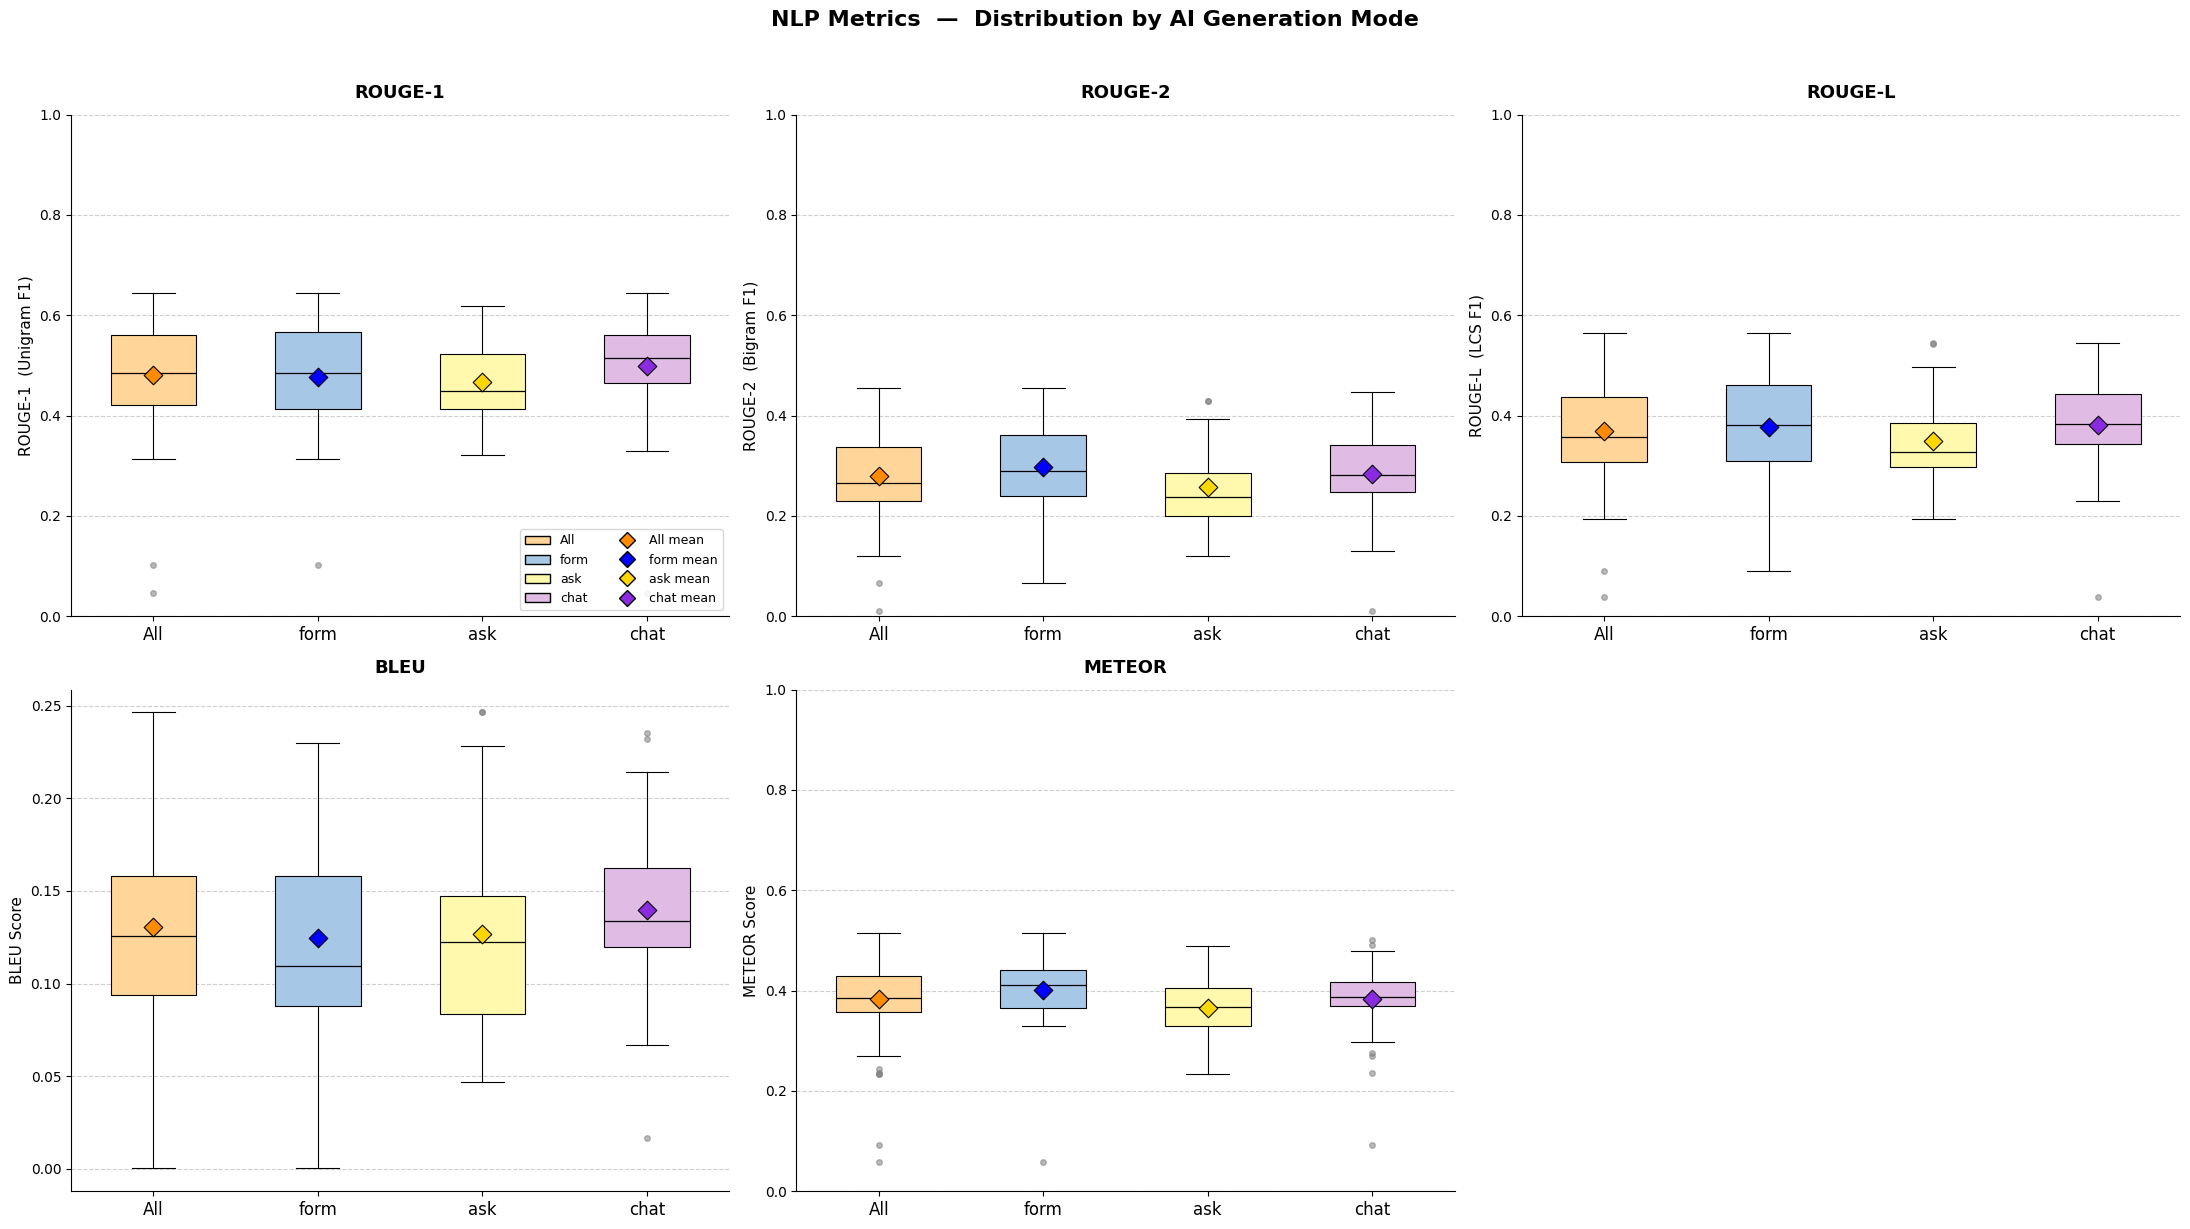

Saved → output/nlp_metrics_boxplot.png


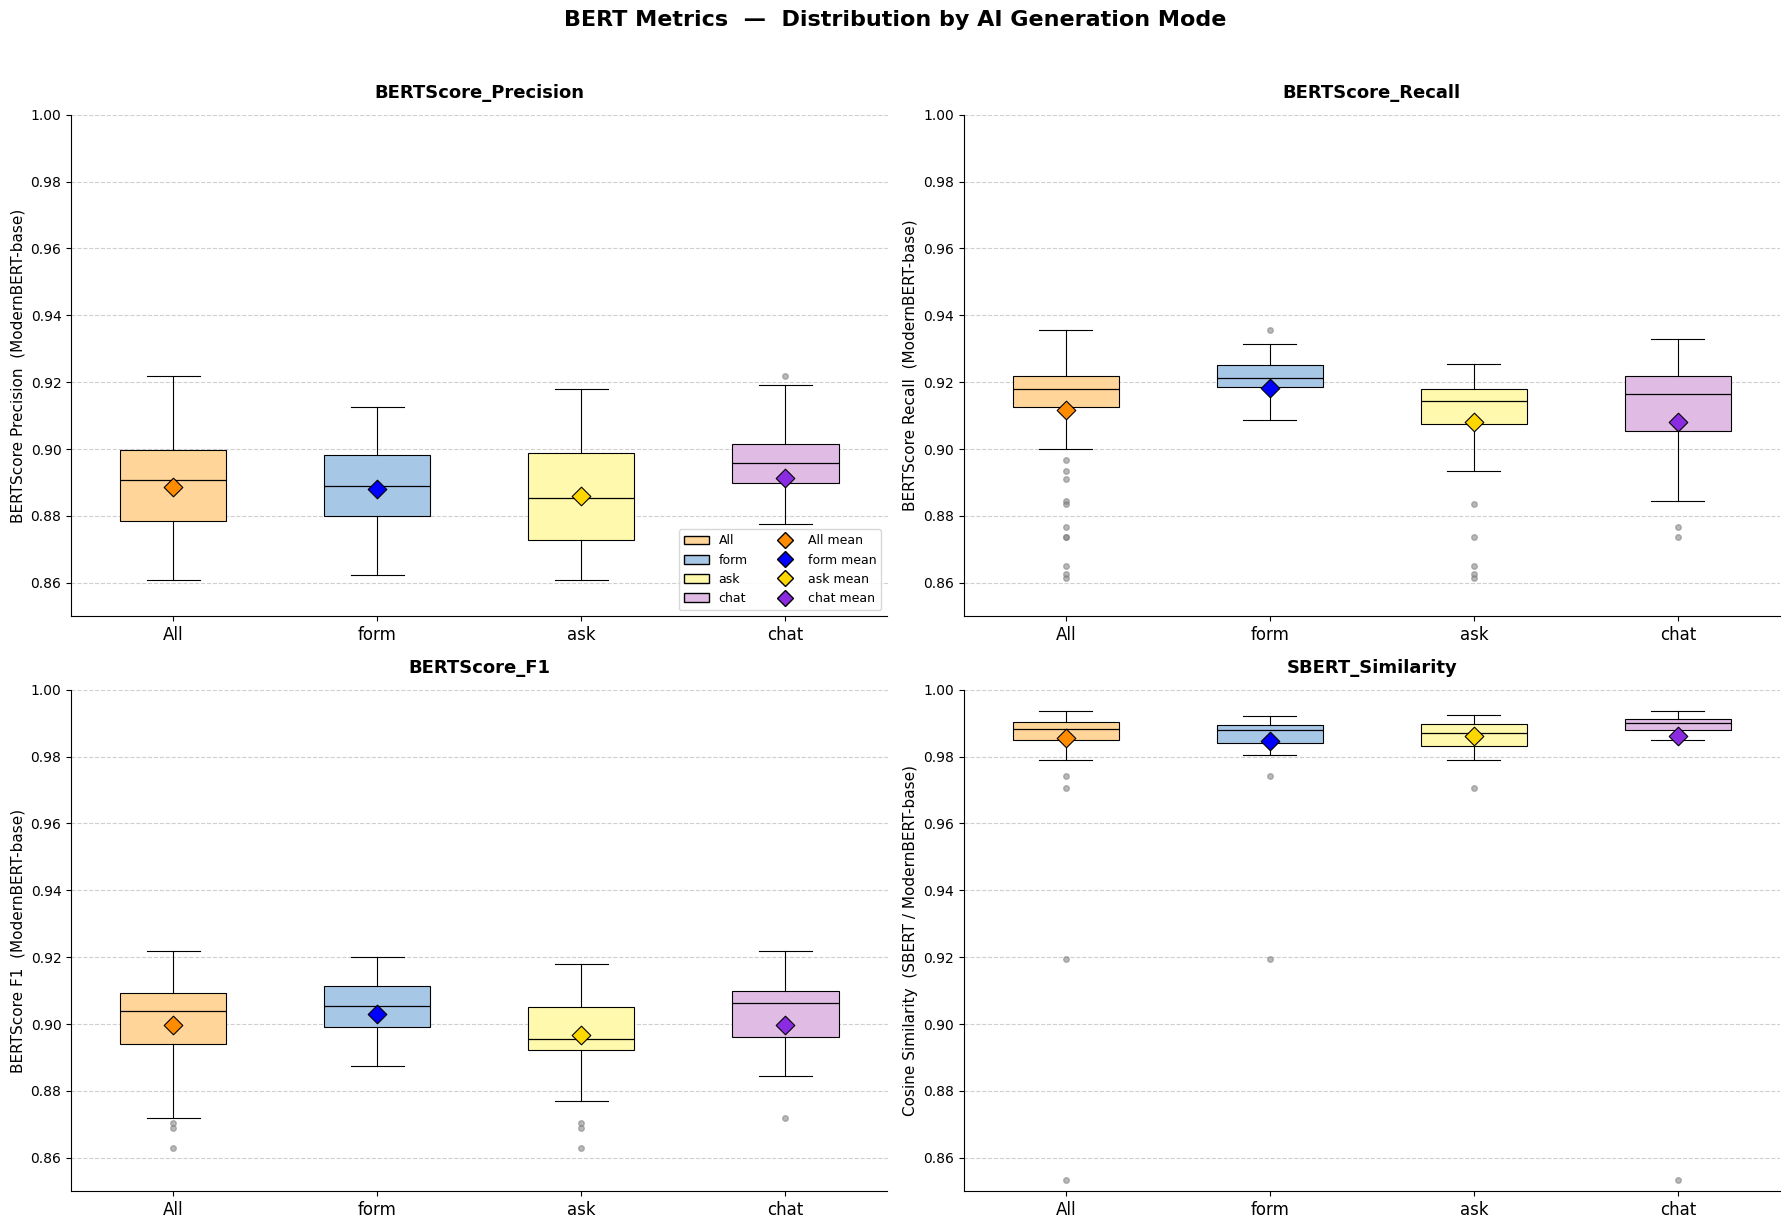

Saved → output/bert_metrics_boxplot.png


In [13]:
# ── Per-metric boxplots ────────────────────────────────────────────────────────
OUT = "output"

METRIC_META = [
    ("ROUGE-1",              "ROUGE-1  (Unigram F1)",                     (0.0, 1.0)),
    ("ROUGE-2",              "ROUGE-2  (Bigram F1)",                      (0.0, 1.0)),
    ("ROUGE-L",              "ROUGE-L  (LCS F1)",                         (0.0, 1.0)),
    ("BLEU",                 "BLEU Score",                                    None),
    ("METEOR",               "METEOR Score",                                   (0.0, 1.0)),
    ("BERTScore_Precision",  "BERTScore Precision  (ModernBERT-base)",        (0.85, 1.00)),
    ("BERTScore_Recall",     "BERTScore Recall  (ModernBERT-base)",           (0.85, 1.00)),
    ("BERTScore_F1",         "BERTScore F1  (ModernBERT-base)",               (0.85, 1.00)),
    ("SBERT_Similarity",     "Cosine Similarity  (SBERT / ModernBERT-base)",  (0.85, 1.00)),
]

NLP_METRICS  = METRIC_META[:5]   # BLEU, ROUGE-1/2/L, METEOR
BERT_METRICS = METRIC_META[5:]   # BERTScore P/R/F1, SBERT

GROUPS      = ["All",     "form",    "ask",     "chat"]
BOX_COLORS  = ["#FFD59A", "#A7C7E7", "#FFF9AE", "#E0BBE4"]
MEAN_COLORS = ["#FF8C00", "#0000FF", "#FFD700", "#8A2BE2"]


def _get_metric(metric: str, mode_key: str) -> np.ndarray:
    if mode_key == "All":
        return df_combined[metric].dropna().values
    df_m = mode_results.get(mode_key)
    if df_m is None or df_m.empty:
        return np.array([])
    return df_m[metric].dropna().values


def _draw_metric(ax, metric, ylabel, ylim, add_legend=False):
    group_data = [_get_metric(metric, g) for g in GROUPS]

    bp = ax.boxplot(
        group_data,
        positions=range(len(GROUPS)),
        widths=0.52,
        patch_artist=True,
        showfliers=True,
        medianprops=dict(color="black", linewidth=0.9),
        whiskerprops=dict(color="black", linewidth=0.8),
        capprops=dict(color="black", linewidth=0.8),
        boxprops=dict(linewidth=0.8),
        flierprops=dict(marker="o", markerfacecolor="grey",
                        markeredgecolor="grey", markersize=4, alpha=0.55),
    )

    for patch, box_col in zip(bp["boxes"], BOX_COLORS):
        patch.set_facecolor(box_col)
        patch.set_edgecolor("black")

    for i, (data, mean_col) in enumerate(zip(group_data, MEAN_COLORS)):
        if len(data) == 0:
            continue
        ax.scatter(i, np.mean(data), marker="D", s=90,
                   color=mean_col, edgecolors="black", linewidths=0.8, zorder=6)

    ax.set_xticks(range(len(GROUPS)))
    ax.set_xticklabels(GROUPS, fontsize=12)
    if ylim:
        ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(metric, fontsize=13, fontweight="bold", pad=12)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    box_patches = [
        mpatches.Patch(facecolor=bc, edgecolor="black", label=g)
        for g, bc in zip(GROUPS, BOX_COLORS)
    ]
    mean_handles = [
        plt.Line2D([0], [0], marker="D", color="w",
                   markerfacecolor=mc, markeredgecolor="black",
                   markersize=8, label=f"{g} mean")
        for g, mc in zip(GROUPS, MEAN_COLORS)
    ]
    if add_legend:
        ax.legend(handles=box_patches + mean_handles, loc="lower right",
                  fontsize=9, ncol=2, framealpha=0.88, edgecolor="lightgrey")


# ── PNG 1: NLP Metrics (BLEU · ROUGE-1/2/L · METEOR) — 2×3 grid ───────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

for i, (metric, ylabel, ylim) in enumerate(NLP_METRICS):
    _draw_metric(axes[i], metric, ylabel, ylim, add_legend=(i == 0))

fig.delaxes(axes[5])  # remove 6th empty slot

plt.suptitle("NLP Metrics  —  Distribution by AI Generation Mode", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
fname_nlp = f"{OUT}/nlp_metrics_boxplot.png"
plt.savefig(fname_nlp, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved \u2192 {fname_nlp}")


# ── PNG 2: BERT Metrics (Precision · Recall · F1 · SBERT) — 2×2 grid ──────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, (metric, ylabel, ylim) in enumerate(BERT_METRICS):
    _draw_metric(axes[i], metric, ylabel, ylim, add_legend=(i == 0))

plt.suptitle("BERT Metrics  —  Distribution by AI Generation Mode", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
fname_bert = f"{OUT}/bert_metrics_boxplot.png"
plt.savefig(fname_bert, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved \u2192 {fname_bert}")
